# Stroke Prediction Dataset EDA

The purpose of this notebook is to perform basic exploratory data analysis (EDA) on the Stroke Prediction Dataset that will be used within the pipeline, to produce synthetic health data and its evaluation.

This analysis will be used to drive data processing decisions for the downstream processes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("../data/raw/healthcare-dataset-stroke-data.csv")

# Data
Get basic information about the data in the dataset.

## Data sample

In [3]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**Note:** raw record-level rows are printed here because the data is public
and non-sensitive. In a real Trusted Research Environment operating under
this project's stated posture (Section 2 of the project statement), sample
rows would be a disclosure-controlled output, not printed directly into a
notebook.

## Dataset columns and their types

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
numerical_columns = ['age', 'avg_glucose_level', 'bmi']
categorical_columns = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
binary_columns = ['hypertension', 'heart_disease']

# Data Visualisation

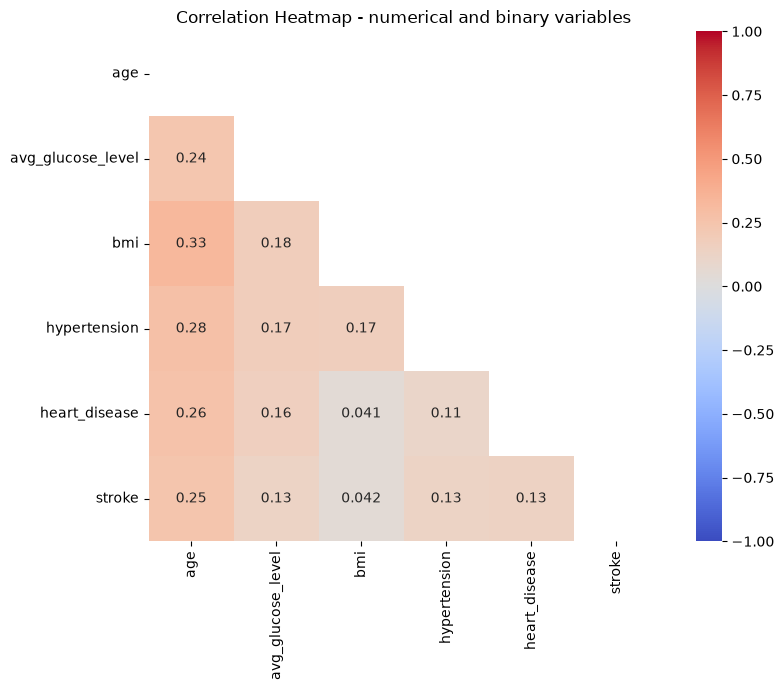

In [6]:
# Correlation matrix
corr = data[numerical_columns + binary_columns + ['stroke']].corr()

# Upper triangle mask
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, annot=True, square=True)
plt.title("Correlation Heatmap - numerical and binary variables")
plt.tight_layout()
plt.show()

## Cramer's V Matrix - Categorical variables

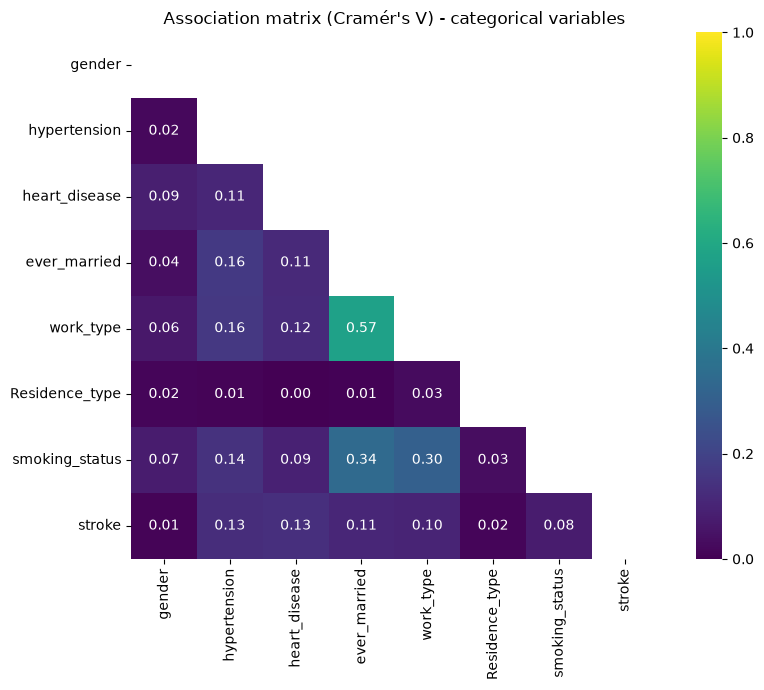

In [7]:
from scipy.stats.contingency import association

def cramers_v_matrix(df, cols):
    n = len(cols)
    mat = pd.DataFrame(np.ones((n, n)), index=cols, columns=cols)
    for i in range(n):
        for j in range(i + 1, n):
            ct = pd.crosstab(df[cols[i]], df[cols[j]])
            v = association(ct, method="cramer")
            mat.iloc[i, j] = mat.iloc[j, i] = v
    return mat

cat_corr = cramers_v_matrix(data, categorical_columns + ['stroke'])
mask = np.triu(np.ones_like(cat_corr, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(cat_corr, mask=mask, cmap="viridis", vmin=0, vmax=1,
            annot=True, fmt=".2f", square=True)
plt.title("Association matrix (Cramér's V) - categorical variables")
plt.tight_layout()
plt.show()

**Decision:** No multi-level categorical variable is promoted to a named *outcome* fidelity check, but strong inter-variable associations are noted.

**Evidence:** In the correlation matrix, `stroke` correlates most with `age` (0.25), then `avg_glucose_level`, `hypertension`, and `heart_disease` (0.13). The Cramér's V matrix shows the same for `hypertension`/`heart_disease` (0.13) and weak association between `stroke` and the multi-level categoricals. Stronger associations exist between variables themselves, such as `age` to `bmi` (0.33), `hypertension` (0.28), and `heart-disease` (0.26), as well as `work_type` to `ever_married` (0.57), and lower for `smoking_status` to `ever_married` (0.34) and `work_type` (0.30). The latter variable correlations are independent of the outcome.

**Consequence:** Named outcome-fidelity checks focus on the stroke-associated relationships in Key Relationships. The strong predictor-to-predictor associations are additional relationships the synthetic data must preserve. Overall multivariate fidelity is assessed by comparing the full real and synthetic association matrices, not only the stroke row. Correlations involving `stroke` are attenuated by class imbalance, so rate-based views are the primary read on outcome strength.

## Distribution Plots of numeric variables

In [8]:
data[numerical_columns].describe()

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000


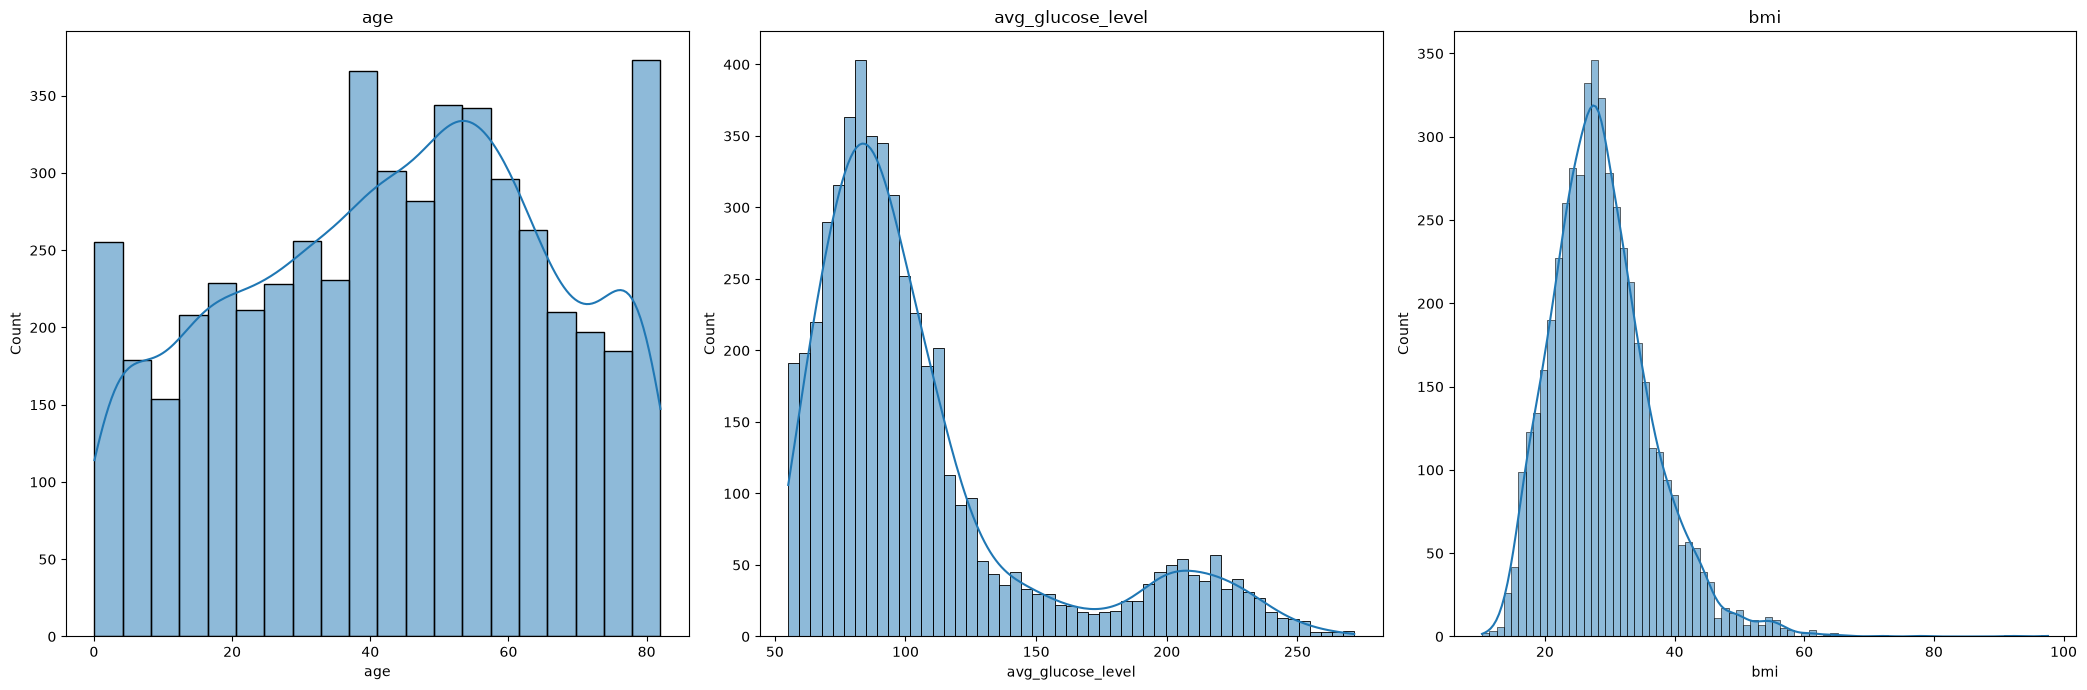

In [9]:
plt.figure(figsize=(21, 7))
for i, col in enumerate(numerical_columns):
    plt.subplot(1, 3, i + 1)
    sns.histplot(data[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

## Count Plots of categorical variables

In [10]:
print("CATEGORICAL VARIABLES\n")
for col in categorical_columns:
    print(data[col].value_counts())
    print()

CATEGORICAL VARIABLES

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

hypertension
0    4612
1     498
Name: count, dtype: int64

heart_disease
0    4834
1     276
Name: count, dtype: int64

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64



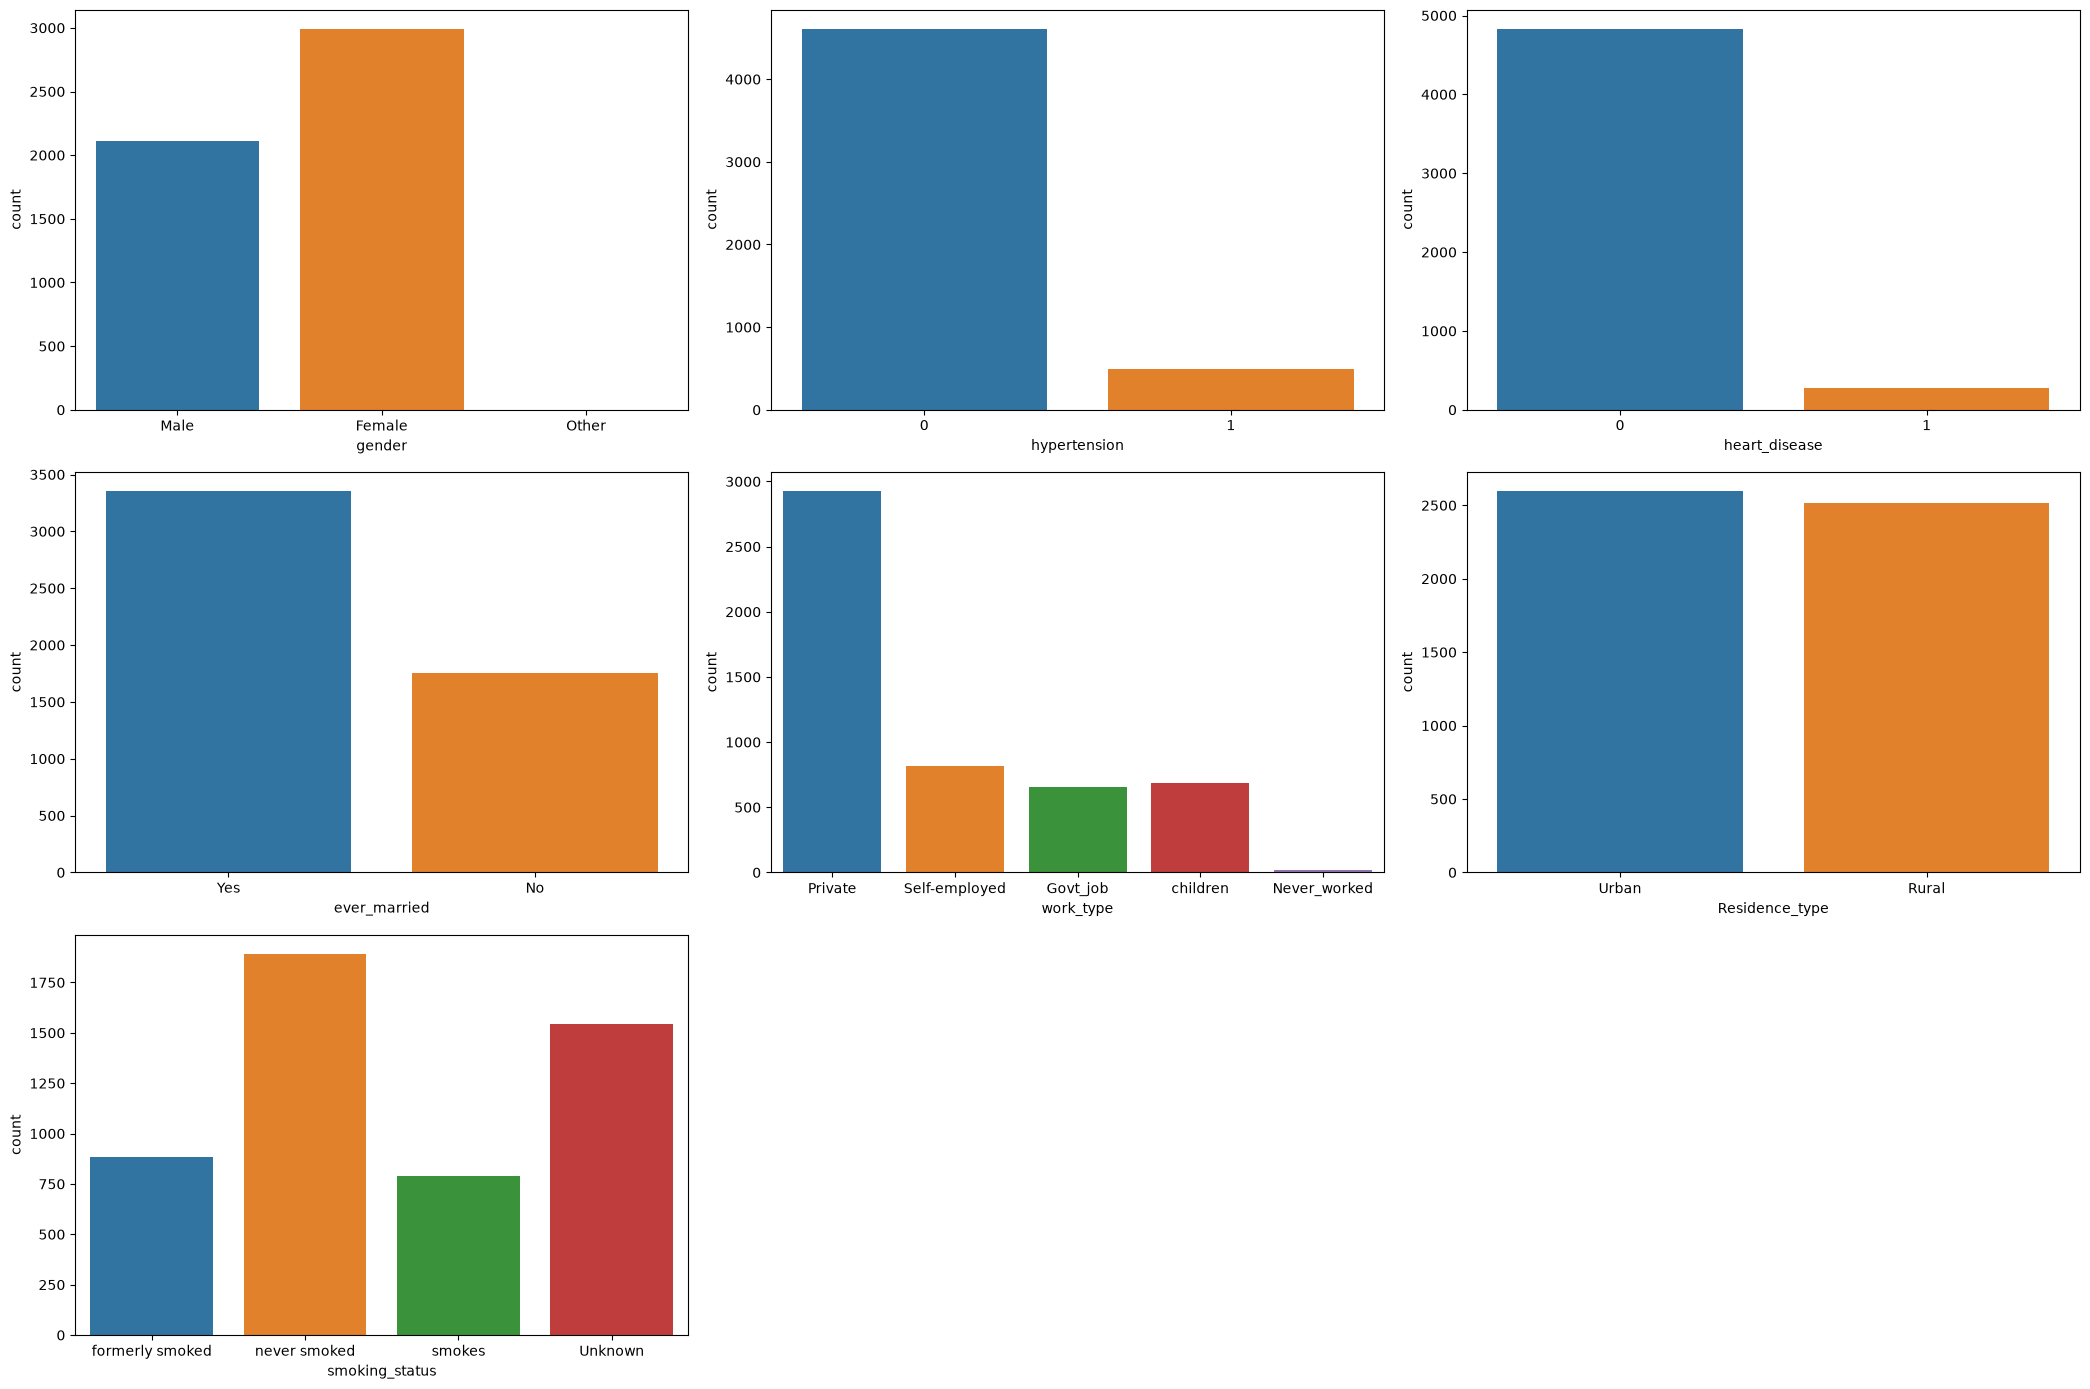

In [11]:
n = len(categorical_columns)
rows = (n + 2) // 3

plt.figure(figsize=(21, 14))
for i, col in enumerate(categorical_columns):
    plt.subplot(rows, 3, i + 1)
    sns.countplot(data=data, hue=col, x=col, legend=False)
plt.tight_layout()
plt.show()

**Decision:** Drop the **"Other"** entry from the `gender` variable.

**Evidence:** It is a single entry, which cannot be used to effectively train a generative model, and poses a significant singling out risk. Folding the entry into any of the other 2 would be an alternative solution. For solution simplicity and avoid accidentally polluting the entries, removal of the single entry would be preferable.

**Consequence:** Drop the singular "Other" gender entry at the point of preprocessing, before splitting the dataset into training and test sets.

# Missingness
Check if there are fields with missing values, their counts, and the percentage of entries that display missingness:

In [12]:
missing = pd.DataFrame({
    "count": data.isnull().sum(),
    "percent": (data.isnull().mean() * 100).round(2)
})
missing[missing["count"] > 0]

,count,percent
bmi,201,3.93


Only `bmi` contains missing values, with **3.93%** being missing

In [13]:
data["bmi_missing"] = data["bmi"].isnull()
data["age_band"] = pd.cut(data["age"], [0, 20, 40, 60, 80, 100])

In [14]:
candidates = ["stroke", "hypertension", "heart_disease", "work_type", "smoking_status", "Residence_type", "age_band"]
for col in candidates:
    print((data.groupby(col, observed=True)["bmi_missing"].mean() * 100).round(2), "\n")

stroke
0     3.31
1    16.06
Name: bmi_missing, dtype: float64 

hypertension
0    3.34
1    9.44
Name: bmi_missing, dtype: float64 

heart_disease
0     3.48
1    11.96
Name: bmi_missing, dtype: float64 

work_type
Govt_job         4.11
Never_worked     0.00
Private          3.90
Self-employed    5.37
children         2.33
Name: bmi_missing, dtype: float64 

smoking_status
Unknown            3.95
formerly smoked    5.42
never smoked       2.11
smokes             6.59
Name: bmi_missing, dtype: float64 

Residence_type
Rural    3.78
Urban    4.08
Name: bmi_missing, dtype: float64 

age_band
(0, 20]      2.44
(20, 40]     2.87
(40, 60]     3.46
(60, 80]     7.24
(80, 100]    0.86
Name: bmi_missing, dtype: float64 



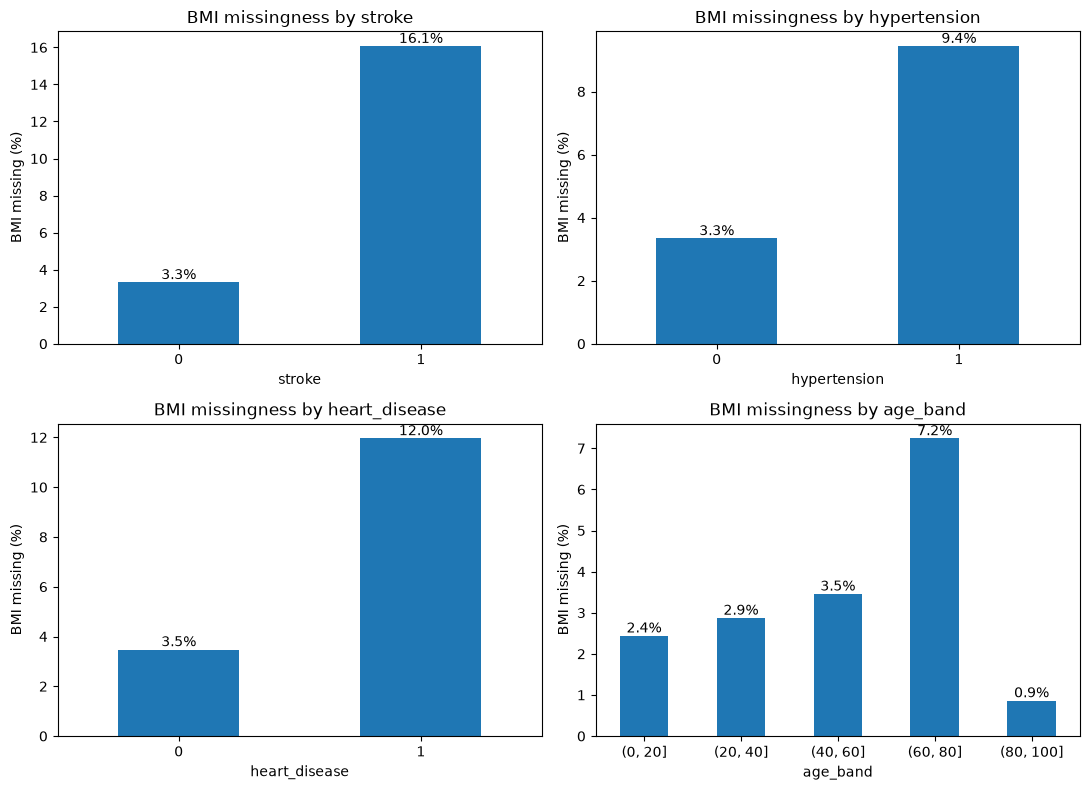

In [15]:
cols = ["stroke", "hypertension", "heart_disease", "age_band"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, cols):
    (data.groupby(col, observed=True)["bmi_missing"].mean() * 100).plot(
        kind="bar", ax=ax, rot=0)
    ax.set(ylabel="BMI missing (%)", xlabel=col, title=f"BMI missingness by {col}")
    ax.bar_label(ax.containers[0], fmt="%.1f%%")

plt.tight_layout()
plt.show()

**Decision:** Preserve the missingness distribution in the synthetic data. Apply no imputation before generation.

**Evidence:** BMI-missingness is non-random - 16.06% (stroke), 9.44% (hypertension), 11.96% (heart_disease) vs a ~3.3% baseline.

**Consequence:** Generators must reproduce missingness. Imputation is applied only inside the TSTR/TRTR pipeline, fit per-training-set, retaining a missing-indicator. Missingness is stored as native NaN in a single column.

# Data Imbalance

Calculate how imbalanced the data is in respect to the outcome, in this case stroke:

In [16]:
stroke_count = len(data[data['stroke'] == 1])
non_stroke_count = len(data[data['stroke'] == 0])
stroke_percent = stroke_count / len(data) * 100
imbalance_ratio = non_stroke_count / stroke_count

print(f"Stroke: {stroke_count}")
print(f"Normal: {non_stroke_count}")
print(f"Stroke outcome percent: {stroke_percent:.2f}%")
print(f"Imbalance ratio (ρ) = {imbalance_ratio:.2f}")

Stroke: 249
Normal: 4861
Stroke outcome percent: 4.87%
Imbalance ratio (ρ) = 19.52


**Decision:** Use stratified sampling on the stroke outcome when splitting into training and test sets.

**Evidence:** Stroke is rare - 249 positives, 4.87% (imbalance ratio ≈ 19.5).

**Consequence:** Stratification ensures the rare positive class is proportionally represented in each split rather than under-represented by chance. The generator is fit on the training set only. The test set is used solely for final evaluation.

# Key Relationships

## Age - Stroke

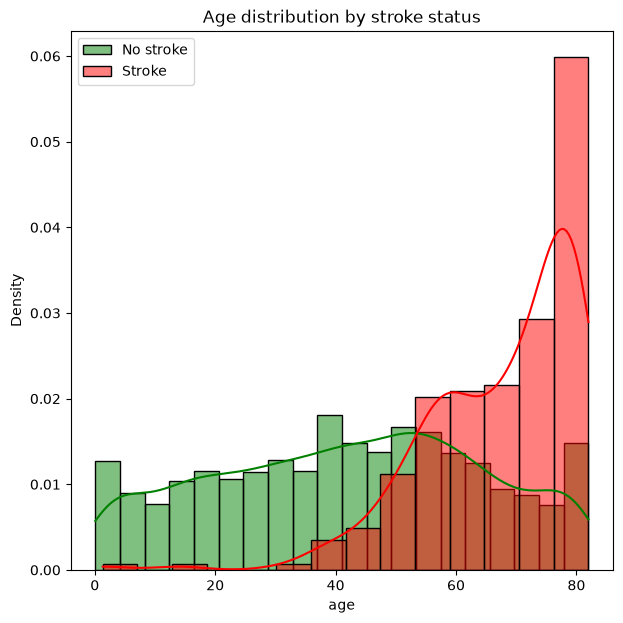

In [17]:
fig = plt.figure(figsize=(7, 7))
sns.histplot(data[data['stroke'] == 0]['age'], stat='density', kde=True, color='green', label='No stroke')
sns.histplot(data[data['stroke'] == 1]['age'], stat='density', kde=True, color='red', label='Stroke')
plt.title("Age distribution by stroke status")
plt.legend()
plt.show()

## Glucose Levels - Stroke

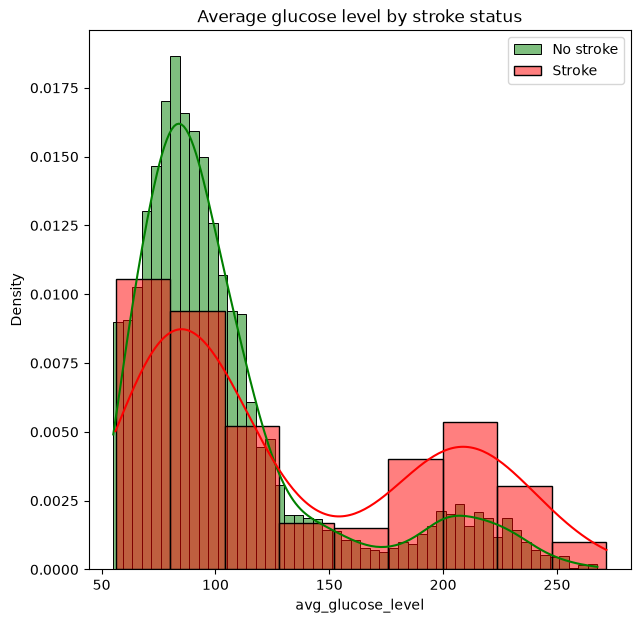

In [18]:
fig = plt.figure(figsize=(7, 7))
sns.histplot(data[data['stroke'] == 0]['avg_glucose_level'], stat='density', kde=True, color='green', label='No stroke')
sns.histplot(data[data['stroke'] == 1]['avg_glucose_level'], stat='density', kde=True, color='red', label='Stroke')
plt.title("Average glucose level by stroke status")
plt.legend()
plt.show()

## BMI - Stroke

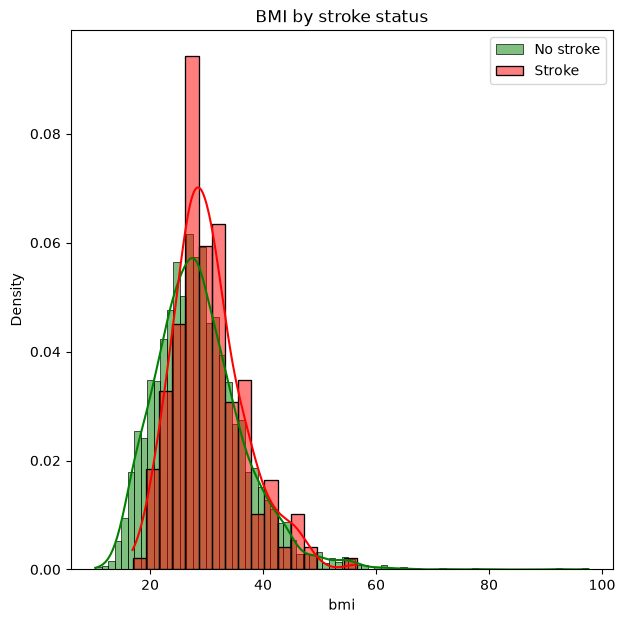

In [19]:
fig = plt.figure(figsize=(7, 7))
sns.histplot(data[data['stroke'] == 0]['bmi'], stat='density', kde=True, color='green', label='No stroke')
sns.histplot(data[data['stroke'] == 1]['bmi'], stat='density', kde=True, color='red', label='Stroke')
plt.title("BMI by stroke status")
plt.legend()
plt.show()

In [20]:
non_stroke = data[data['stroke'] == 0]['bmi']
stroke = data[data['stroke'] == 1]['bmi']

non_stroke_mean = non_stroke.mean()
stroke_mean = stroke.mean()

print(f"Non stroke mean: {non_stroke_mean:.2f}")
print(f"Stroke mean: {stroke_mean:.2f}")
print(f"Distribution shift: {stroke_mean - non_stroke_mean:.2f}")

Non stroke mean: 28.82
Stroke mean: 30.47
Distribution shift: 1.65


## Hypertension - Stroke

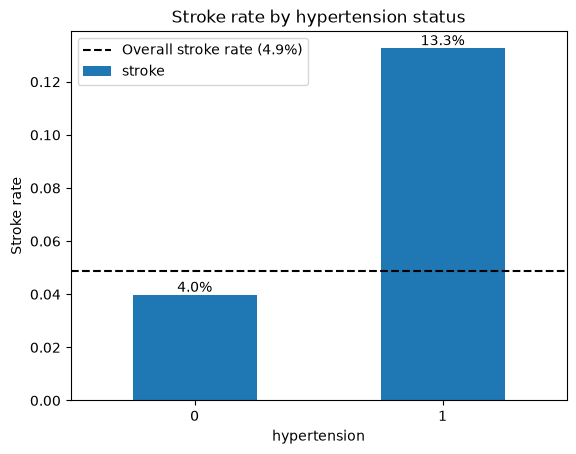

In [21]:
overall = data["stroke"].mean()
rate = data.groupby("hypertension")["stroke"].mean()
ax = rate.plot(kind="bar", rot=0, ylabel="Stroke rate", title="Stroke rate by hypertension status")
ax.axhline(overall, color="black", ls="--", label=f"Overall stroke rate ({overall:.1%})")
ax.bar_label(ax.containers[0], fmt="{:.1%}".format)
ax.legend()

## Heart Disease - Stroke

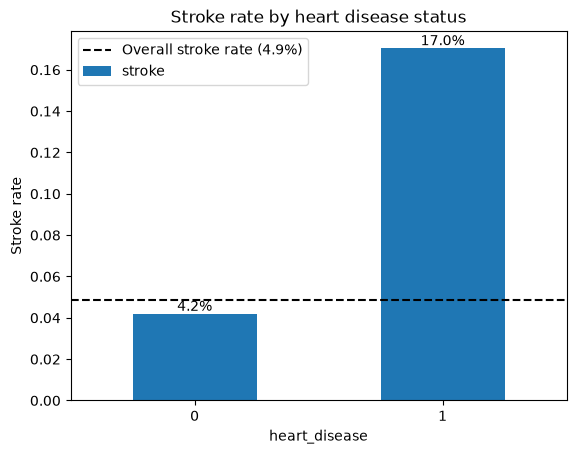

In [22]:
overall = data["stroke"].mean()
rate = data.groupby("heart_disease")["stroke"].mean()
ax = rate.plot(kind="bar", rot=0, ylabel="Stroke rate", title="Stroke rate by heart disease status")
ax.axhline(overall, color="black", ls="--", label=f"Overall stroke rate ({overall:.1%})")
ax.bar_label(ax.containers[0], fmt="{:.1%}".format)
ax.legend()

## Smoking - Stroke

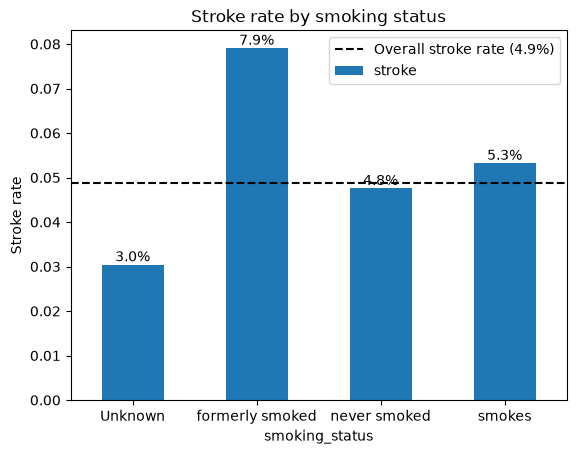

In [23]:
overall = data["stroke"].mean()
rate = data.groupby("smoking_status")["stroke"].mean()
ax = rate.plot(kind="bar", rot=0, ylabel="Stroke rate", title="Stroke rate by smoking status")
ax.axhline(overall, color="black", ls="--", label=f"Overall stroke rate ({overall:.1%})")
ax.bar_label(ax.containers[0], fmt="{:.1%}".format)
ax.legend()

**Observation:** The plots confirm the expected clinical relationships: stroke rate rises sharply with `age`, is elevated for `hypertension` and `heart_disease` (both well above the ~4.9% overall rate), and is higher in the upper `avg_glucose_level` range. `smoking_status` shows a weaker, less consistent signal. `bmi` shows a slight right shift in the distribution, for stroke outcomes over non-stroke outcomes, with the difference between the two distribution means being about 1.65 points.

**Consequence:** `age`-stroke, `hypertension`-stroke, `heart_disease`-stroke, and `avg_glucose_level`-stroke are adopted as the named multivariate fidelity checks. Synthetic data will be evaluated on whether it reproduces these specific relationships, not only the aggregate association matrices. `smoking_status` and `bmi` are not adopted as named checks.

# Extreme Values & Rare Combinations

## Data Ranges

In [24]:
numeric_data = data[numerical_columns]
extremes = pd.DataFrame({
    "min": numeric_data.min(),
    "max": numeric_data.max()
})
extremes

,min,max
age,0.08,82.00
avg_glucose_level,55.12,271.74
bmi,10.30,97.60


## Rare Combinations

In [25]:
combo = data.groupby(categorical_columns).size().reset_index(name="count")

k = 5
print("total combinations:", len(combo))
print("unique (n=1):", (combo["count"] == 1).sum())
print(f"near-unique (n<={k}):", (combo["count"] <= k).sum())
print("rows in near-unique combinations:", combo.loc[combo["count"] <= k, "count"].sum())

combo.sort_values("count").head(10)

total combinations: 281
unique (n=1): 50
near-unique (n<=5): 156
rows in near-unique combinations: 370


,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,count
280,Other,0,0,No,Private,Rural,formerly smoked,1
70,Female,0,1,Yes,Private,Rural,Unknown,1
67,Female,0,1,Yes,Govt_job,Rural,smokes,1
66,Female,0,1,Yes,Govt_job,Rural,Unknown,1
65,Female,0,1,No,Self-employed,Urban,never smoked,1
63,Female,0,1,No,Self-employed,Rural,formerly smoked,1
59,Female,0,1,No,Private,Rural,formerly smoked,1
199,Male,0,1,No,Private,Rural,formerly smoked,1
58,Female,0,1,No,Govt_job,Urban,Unknown,1
202,Male,0,1,No,Private,Urban,smokes,1


## Rare Combinations based only on Quasi-Identifiers

In [26]:
cats = ["gender", "ever_married", "work_type", "Residence_type", "age_band"]

combo = data.groupby(cats, observed=True).size().reset_index(name="count")

k = 5
print("total combinations:", len(combo))
print("unique (n=1):", (combo["count"] == 1).sum())
print(f"near-unique (n<={k}):", (combo["count"] <= k).sum())
print("rows in near-unique combinations:", combo.loc[combo["count"] <= k, "count"].sum())

combo.sort_values("count").head(10)

total combinations: 118
unique (n=1): 10
near-unique (n<=5): 37
rows in near-unique combinations: 102


,gender,ever_married,work_type,Residence_type,age_band,count
117,Other,No,Private,Rural,"(20, 40]",1
20,Female,No,Private,Urban,"(80, 100]",1
68,Male,No,Never_worked,Urban,"(20, 40]",1
73,Male,No,Private,Rural,"(80, 100]",1
78,Male,No,Private,Urban,"(80, 100]",1
8,Female,No,Govt_job,Urban,"(80, 100]",1
35,Female,Yes,Govt_job,Rural,"(80, 100]",1
98,Male,Yes,Govt_job,Urban,"(80, 100]",1
104,Male,Yes,Private,Urban,"(0, 20]",1
99,Male,Yes,Private,Rural,"(0, 20]",1


**Decision:** Keep rare combinations, but run strict privacy checks for singling out, disclosure, and attribute inference attacks.

**Evidence:** Rare combinations analysis on all categorical variables, and just on quasi-identifiers show unique and near-unique combinations highlighting potential disclosure risks.

**Consequence:** Generation is not affected. Privacy checks need to be rigorous, especially for Level 3 fidelity.

# Duplicate Rows

In [27]:
print(f"Number of duplicate rows: {data.drop(columns='id').duplicated().sum()}")

Number of duplicate rows: 0


**Decision:** No deduplication.

**Evidence:** After excluding the `id` identifier, 0 duplicate rows are present.

**Consequence:** No deduplication step in preprocessing.

# Decisions:

**1. Drop the 'id' field in preprocessing. It is an identifier with no analytical value and no purpose in a single-table dataset.**

**2. Drop the single 'Other' gender entry. No generative method can learn effectively from one sample, and a unique category value is a direct singling-out risk. With a single instance it does not meaningfully represent a minority group. It is removed at preprocessing, before the train and test split.**

**3. Use stratified sampling on the stroke outcome to split into training and test sets. The generator is fit on the training set only, and the test set is only used for final evaluation. If hyperparameter tuning is later required, a separate validation set is drawn, also by stratified sampling. Stratification ensures the rare positive class (249, 4.87%) is proportionally represented in each split.**

**4. Multivariate fidelity is assessed via the named clinical relationships (age to stroke, hypertension and heart_disease to stroke, glucose to stroke), measured with type-correct statistics (Pearson correlation for numeric to binary, and Cramer's V for categorical). Correlations involving stroke are attenuated by class imbalance, so rate-based views are the primary read on strength. Overall multivariate fidelity also compares the full real and synthetic association matrices, preserving strong predictor to predictor associations (for example age to bmi, and work_type to ever_married), not only stroke-related ones.**

**5. The missing-data distribution is preserved in the synthetic data, with no imputation before generation. BMI-missingness is non-random, at 16.06% (stroke), 9.44% (hypertension), and 11.96% (heart_disease) against a baseline of roughly 3.3%. Imputation occurs only inside the TSTR and TRTR pipeline, fit per-training-set, with a retained missing-indicator.**

**6. Rare combinations are kept, not suppressed. Their disclosure risk is evaluated rather than assumed. Singling-out is reported on quasi-identifiers (attacker model), with all-categoricals uniqueness reported alongside as record rarity. Generation is unaffected. Privacy checks must be rigorous, especially at Level 3 fidelity.**

**7. BMI missing values (encoded as 'N/A' in the source) are parsed to NaN automatically on load. The type was verified as float64 with 201 missing (3.93%). No manual conversion is required.**

**8. No duplicate rows are present after excluding the 'id' identifier, so no deduplication is performed.**

**9. Missingness is stored as native NaN in a single column. A missingness indicator is derived on demand (EDA, evaluation, and the modelling pipeline) and never persisted, to avoid generating internally inconsistent rows.**